In [2]:
from transformers import BertTokenizer, BertModel
import torch
import matplotlib.pyplot as plt
import numpy as np


In [3]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)

In [4]:
text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')
outputs = model(**inputs)

In [5]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

In [6]:
# Look at different heads in layer 6
layer = 6
attention = outputs.attentions[layer][0]  # (num_heads, seq_len, seq_len)

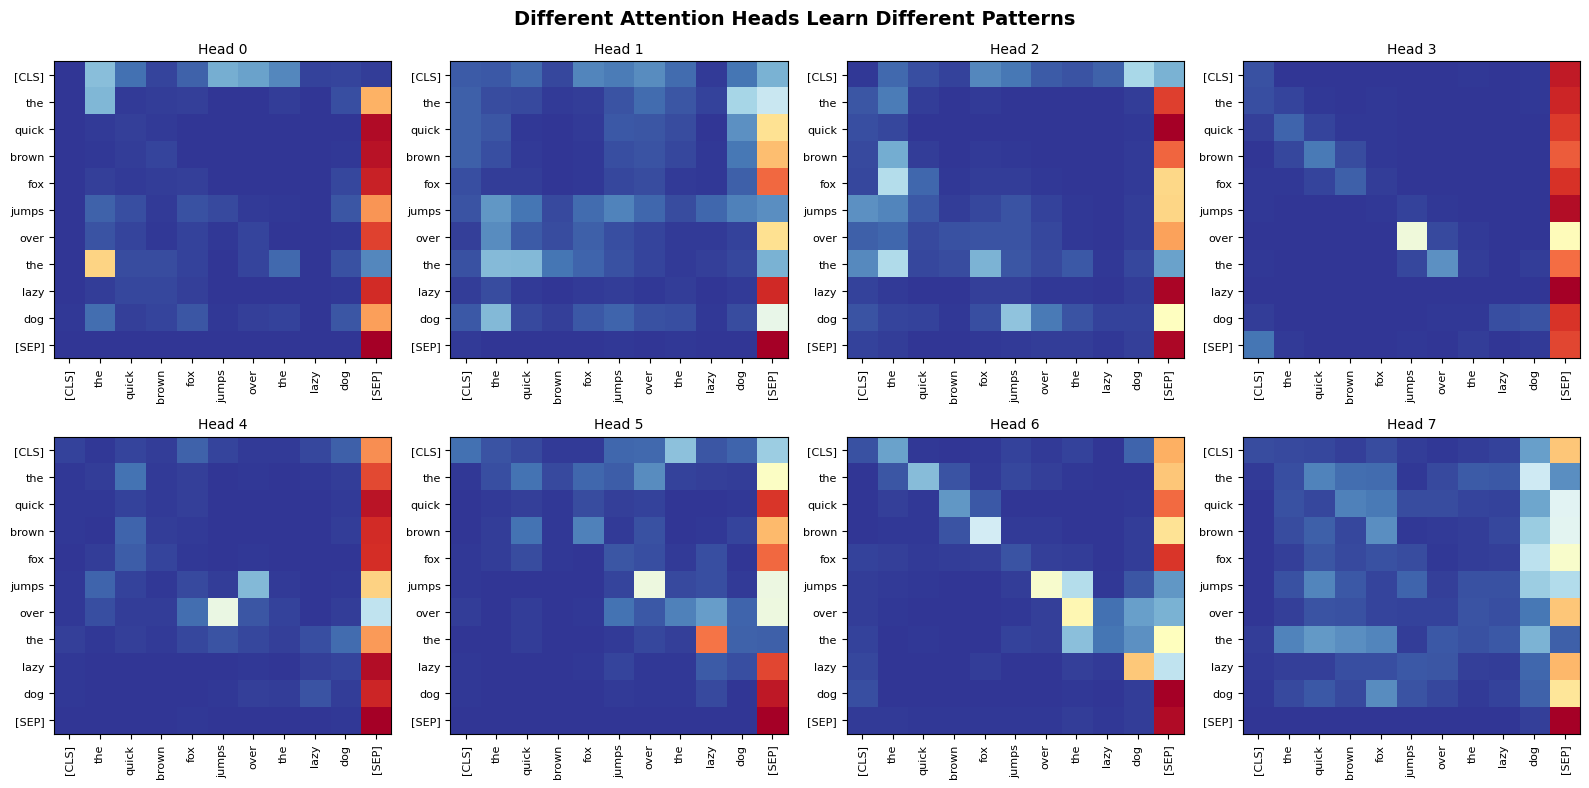

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for head in range(8):
    ax = axes[head]
    attn_head = attention[head].detach().numpy()
    
    im = ax.imshow(attn_head, cmap='RdYlBu_r', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f'Head {head}', fontsize=10)

plt.suptitle('Different Attention Heads Learn Different Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n INSIGHT: Each head specializes!")
print("Some heads focus on:", )
print("  - Syntactic relationships (subject-verb)")
print("  - Positional patterns (next word)")
print("  - Semantic similarity (related concepts)")
print("\nThis emergent specialization = why transformers work!")

# Simple Transformer

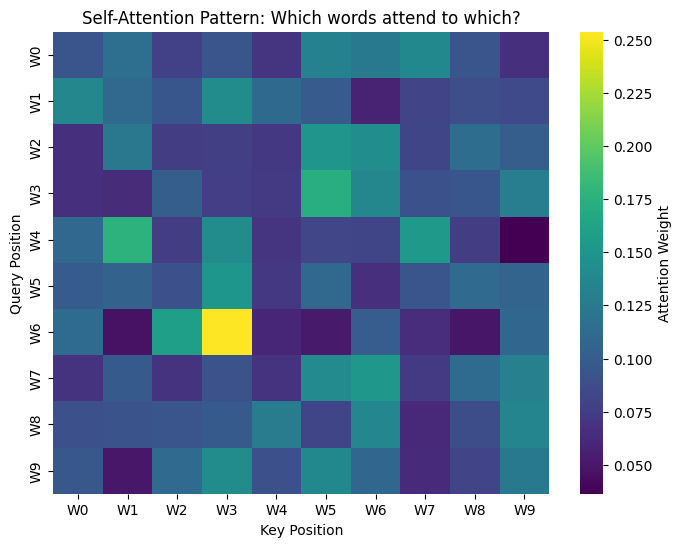

🎯 This is THE core innovation!
Stack 96 of these blocks = GPT-3
Add some clever engineering = ChatGPT


In [ ]:
import torch
import torch.nn as nn
import math

class SimpleAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out = nn.Linear(embed_dim, embed_dim)
        
    def forward(self, x):
        B, T, C = x.shape
        
        # Generate Q, K, V
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, T, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Attention scores
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = torch.softmax(scores, dim=-1)
        
        # Apply attention to values
        out = (attn @ v).transpose(1, 2).reshape(B, T, C)
        return self.out(out), attn

# Demo: Show what the model "pays attention to"
embed_dim = 64
attention = SimpleAttention(embed_dim)

# Create dummy sentence embedding
sentence = torch.randn(1, 10, embed_dim)  # 10 words

output, attn_weights = attention(sentence)

# Visualize attention pattern
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
# Take first head's attention
sns.heatmap(attn_weights[0, 0].detach().numpy(), 
            xticklabels=[f"W{i}" for i in range(10)],
            yticklabels=[f"W{i}" for i in range(10)],
            cmap='viridis', cbar_kws={'label': 'Attention Weight'})
plt.title("Self-Attention Pattern: Which words attend to which?")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()

print("🎯 This is THE core innovation!")
print("Stack 96 of these blocks = GPT-3")
print("Add some clever engineering = ChatGPT")

# Transformer Hallucinations

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



📊 Analyzing: 'The movie was not good at all, I hated it'


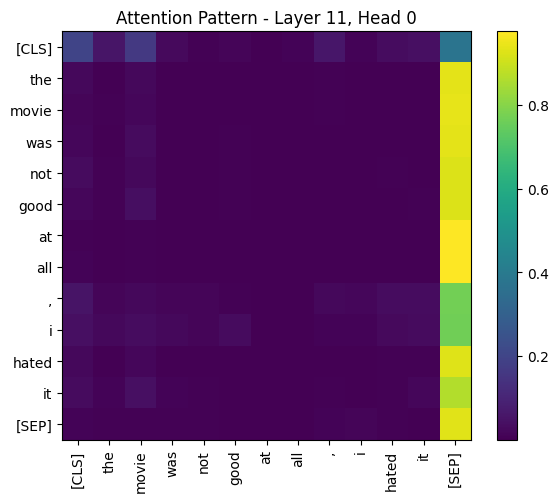

Top attended words: ['[SEP]', '[CLS]', 'movie']

📊 Analyzing: 'Although the acting was great, the plot was terrible'


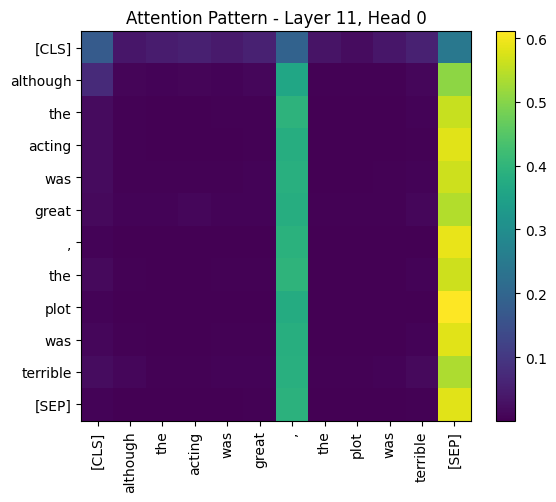

Top attended words: ['[SEP]', ',', '[CLS]']

📊 Analyzing: 'I love love love this product!'


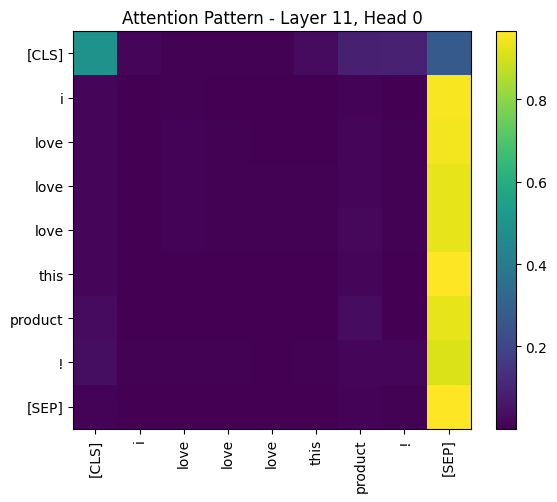

Top attended words: ['[SEP]', '[CLS]', 'product']


In [2]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import numpy as np
import matplotlib.pyplot as plt

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', 
                                                       output_attentions=True)

def visualize_attention(text, layer=11, head=0):
    inputs = tokenizer(text, return_tensors='pt')
    outputs = model(**inputs)
    
    # Get attention from last layer
    attention = outputs.attentions[layer][0, head].detach().numpy()
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(attention, cmap='viridis')
    
    ax.set_xticks(np.arange(len(tokens)))
    ax.set_yticks(np.arange(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)
    
    plt.colorbar(im)
    plt.title(f"Attention Pattern - Layer {layer}, Head {head}")
    plt.tight_layout()
    plt.show()
    
    return attention, tokens

# Try different sentences
sentences = [
    "The movie was not good at all, I hated it",
    "Although the acting was great, the plot was terrible",
    "I love love love this product!",
]

for sent in sentences:

    print(f"\n📊 Analyzing: '{sent}'")
    attn, tokens = visualize_attention(sent)
    
    # Find which words get most attention
    avg_attn = attn.mean(axis=0)
    top_idx = avg_attn.argsort()[-3:][::-1]
    print(f"Top attended words: {[tokens[i] for i in top_idx]}")